# GHG Emissions Prediction Project
ITCS 227 — Data Science Capstone

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

### Imports
This cell imports the necessary libraries for data manipulation, numerical operations, plotting, and styling.

## Step 1 — Load and filter data.

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#### Mount Google Drive
This code mounts your Google Drive to access files stored there. While the current `URL` is a direct path, mounting Drive is a common practice in Colab notebooks.

In [12]:
URL = "/content/owid-co2-data.csv"
df_raw = pd.read_csv(URL)
print(f'Raw shape: {df_raw.shape}')

df_countries = df_raw[
    df_raw['iso_code'].notna() &
    ~df_raw['iso_code'].str.startswith('OWID_', na=False)
].copy()


COLS = [
    'country', 'iso_code', 'year',
    'population', 'gdp',
    'coal_co2', 'oil_co2', 'gas_co2',
    'total_ghg'
]
df = df_countries[COLS].copy()

df = df[(df['year'] >= 1990) & (df['year'] <= 2025)].copy()

# cut the line that's not contain the target
df = df.dropna(subset=['total_ghg']).copy()

print(f'After filter shape: {df.shape}')
print(f'Countries: {df["country"].nunique()}')
print(f'Year range: {df["year"].min()} - {df["year"].max()}')

Raw shape: (50411, 79)
After filter shape: (6965, 9)
Countries: 199
Year range: 1990 - 2024


#### Load and Filter Raw Data
This cell loads the raw `owid-co2-data.csv` file into a DataFrame, filters out non-country specific data, selects relevant columns, and narrows down the year range to 1990-2025. It also removes rows with missing `total_ghg` values.

In [13]:
# Check how many countries have data each year.
print(df_raw[df_raw['year'] >= 2015].groupby('year')['country'].nunique())

year
2015    254
2016    254
2017    254
2018    254
2019    254
2020    254
2021    254
2022    254
2023    254
2024    254
Name: country, dtype: int64


#### Check Country Count per Year
This code snippet verifies how many unique countries have data available for each year from 2015 onwards in the raw dataset. This helps understand data completeness.

## Step 2 — Choose Features and Target

In [14]:
# Sort data by country and year of creation (lag).
df = df.sort_values(['country', 'year']).reset_index(drop=True)

# Create lag features (Last year's value)
df['total_ghg_lag1'] = df.groupby('country')['total_ghg'].shift(1)
df['total_ghg_lag3'] = df.groupby('country')['total_ghg'].shift(3)

# Create log transform of target (Correct skewed data)
df['total_ghg_log'] = np.log1p(df['total_ghg'])

TARGET = 'total_ghg_log'
FEATURES = [
    'gdp',
    'population',
    'coal_co2',
    'oil_co2',
    'gas_co2',
    'total_ghg_lag1',
    'total_ghg_lag3',
]

# Collect all the column that we needed(Included total_ghg and year for EDA)
cols_needed = FEATURES + [TARGET, 'total_ghg', 'country', 'iso_code', 'year']
df_model = df[cols_needed].dropna().copy()

print(f'Model data shape: {df_model.shape}')
print(f'Countries: {df_model["country"].nunique()}')

X = df_model[FEATURES]
y = df_model[TARGET]
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Missing in X: {X.isnull().sum().sum()}')

Model data shape: (2970, 12)
Countries: 109
X shape: (2970, 7)
y shape: (2970,)
Missing in X: 0


#### Feature Engineering and Model Data Preparation
This cell sorts the data, creates lag features (`total_ghg_lag1` and `total_ghg_lag3`) to capture previous year's emissions, applies a log transformation (`np.log1p`) to the target variable (`total_ghg`) to handle its skewed distribution, defines the `TARGET` and `FEATURES` lists, and finally creates `df_model` by dropping rows with any missing values in the selected columns. It then separates features (`X`) and target (`y`).

## Step 3 — EDA

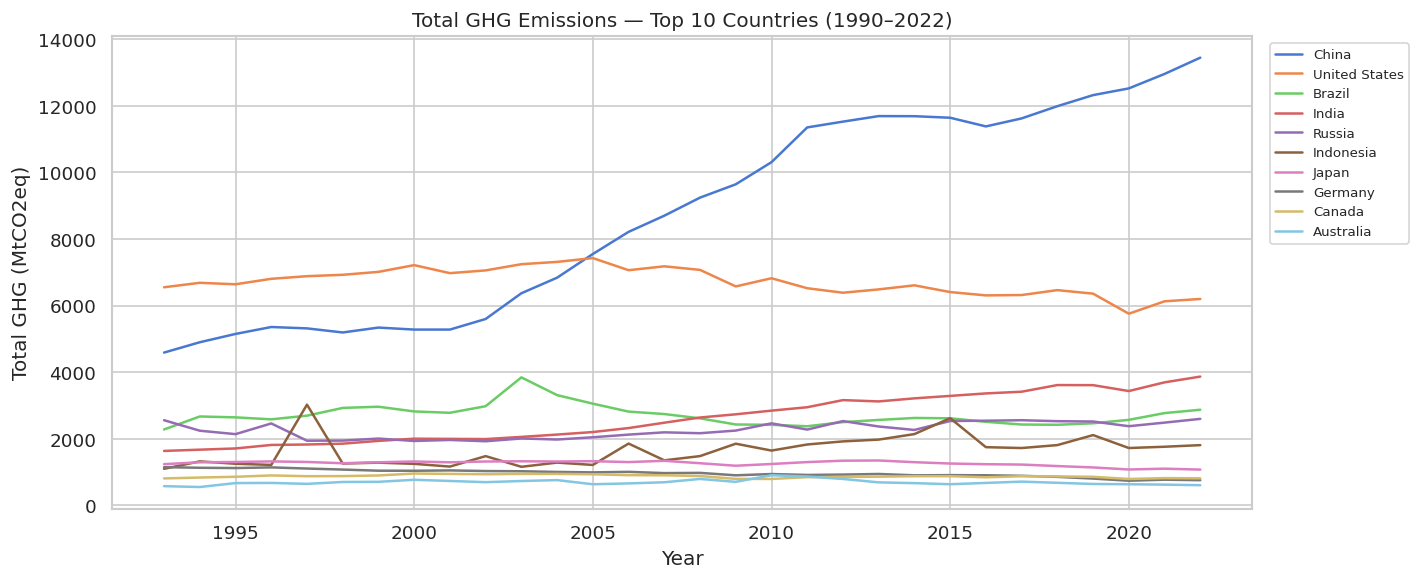

In [15]:
# Graph 1: Trend Top 10 Contries
top10 = (
    df_model.groupby('country')['total_ghg']
    .mean().nlargest(10).index.tolist()
)
df_top10 = df_model[df_model['country'].isin(top10)]

plt.figure(figsize=(12, 5))
for c in top10:
    d = df_top10[df_top10['country'] == c]
    plt.plot(d['year'], d['total_ghg'], label=c, linewidth=1.5)
plt.title('Total GHG Emissions — Top 10 Countries (1990–2022)')
plt.xlabel('Year')
plt.ylabel('Total GHG (MtCO2eq)')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('eda_01_top10_trend.png')
plt.show()

#### Graph 1: Total GHG Emissions — Top 10 Countries Trend
This plot visualizes the historical trend of total greenhouse gas emissions for the top 10 countries with the highest average emissions, providing insight into their emission trajectories over the years.

/tmp/ipykernel_944/1162276615.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top15, x='avg_ghg', y='country', palette='rocket_r')


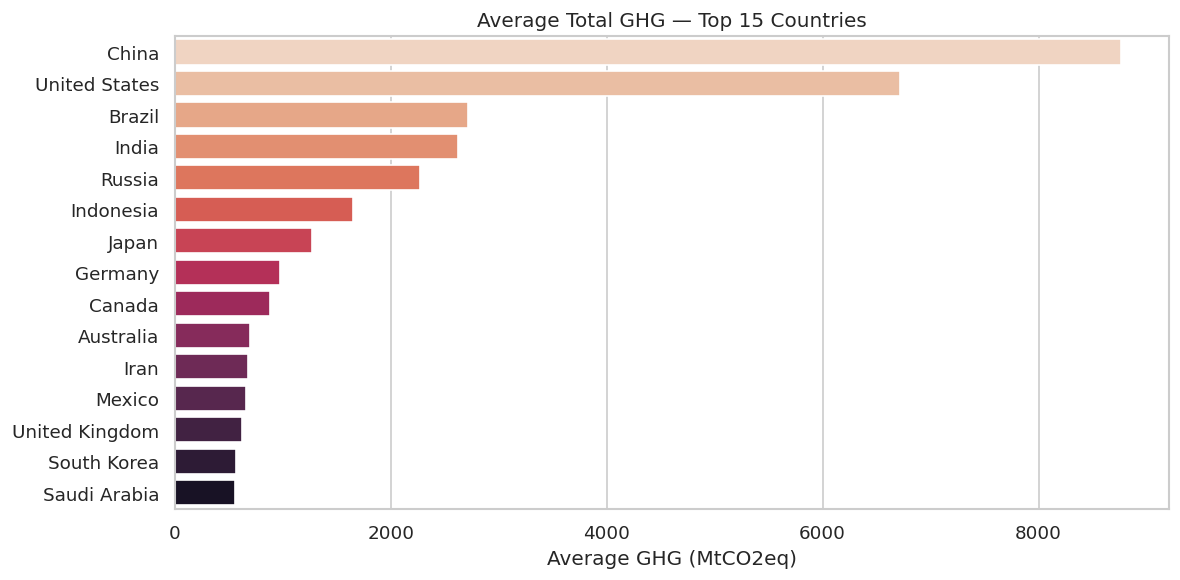

In [16]:
# Garph 2: Bar chart Top 15 Countries
top15 = (
    df_model.groupby('country')['total_ghg']
    .mean().nlargest(15).reset_index()
)
top15.columns = ['country', 'avg_ghg']

plt.figure(figsize=(10, 5))
sns.barplot(data=top15, x='avg_ghg', y='country', palette='rocket_r')
plt.title('Average Total GHG — Top 15 Countries')
plt.xlabel('Average GHG (MtCO2eq)')
plt.ylabel('')
plt.tight_layout()
plt.savefig('eda_02_top15_bar.png')
plt.show()

#### Graph 2: Average Total GHG — Top 15 Countries Bar Chart
This bar chart displays the average total greenhouse gas emissions for the top 15 countries, offering a clear comparison of their contribution to global emissions.

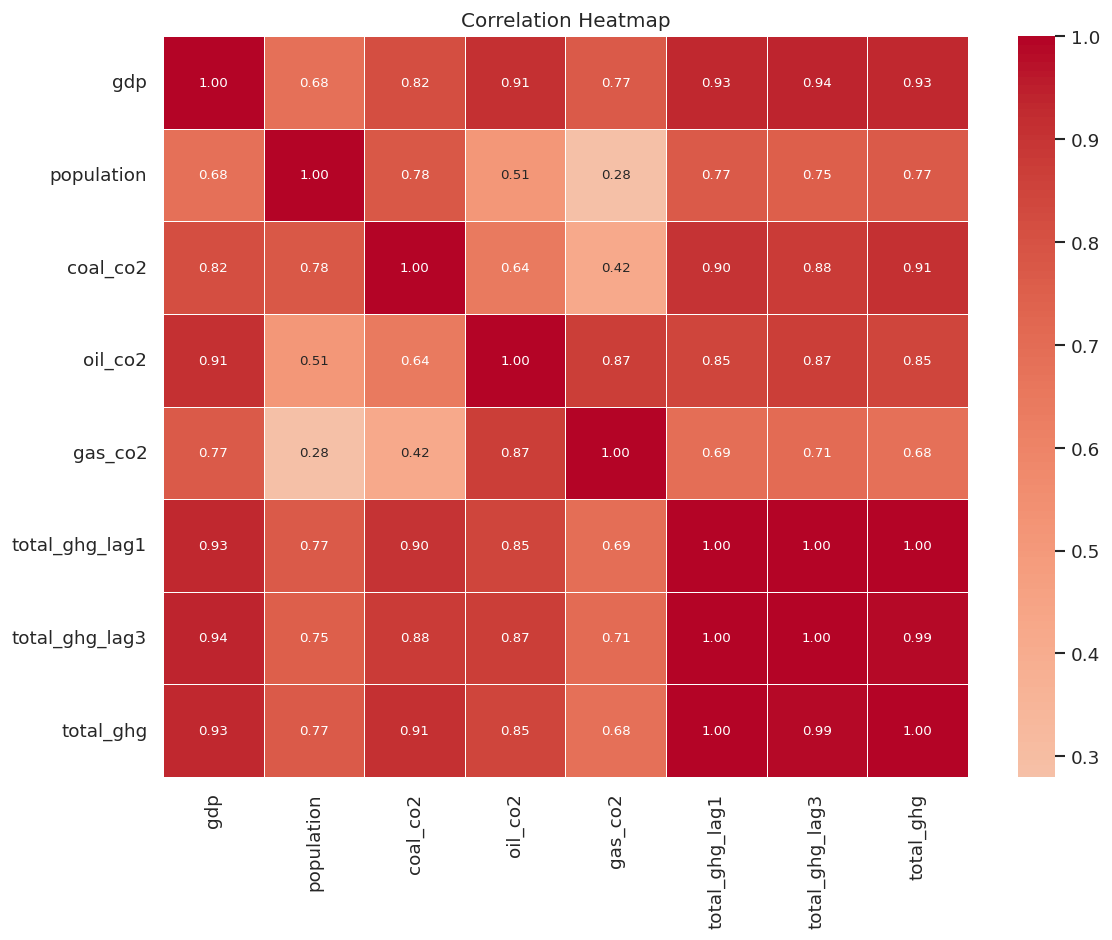


--- Correlation and total_ghg (Descending) ---
total_ghg_lag1    1.00
total_ghg_lag3    0.99
gdp               0.93
coal_co2          0.91
oil_co2           0.85
population        0.77
gas_co2           0.68


In [17]:
# Garph 3: Correlation Heatmap
HEATMAP_COLS = FEATURES + ['total_ghg']
corr = df_model[HEATMAP_COLS].corr().round(2)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('eda_03_correlation.png')
plt.show()

# Summarize correlation and total_ghg
print('\n--- Correlation and total_ghg (Descending) ---')
print(corr['total_ghg'].drop('total_ghg').sort_values(ascending=False).to_string())

#### Graph 3: Correlation Heatmap
This heatmap visualizes the correlation matrix between the selected features and the `total_ghg` target. It helps identify relationships and the strength of correlation between variables, which is crucial for feature selection.

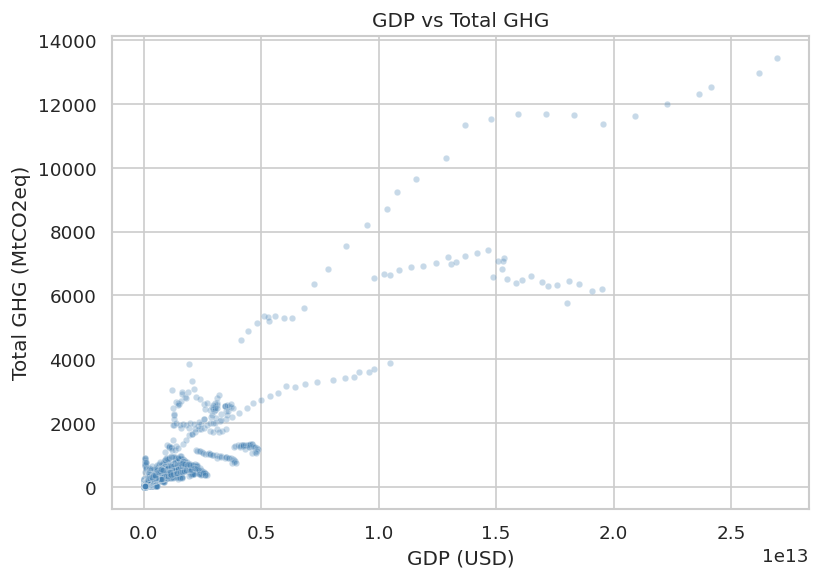

In [18]:
# Garph 4: GDP vs GHG
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df_model, x='gdp', y='total_ghg',
                alpha=0.3, s=15, color='steelblue')
plt.title('GDP vs Total GHG')
plt.xlabel('GDP (USD)')
plt.ylabel('Total GHG (MtCO2eq)')
plt.tight_layout()
plt.savefig('eda_04_gdp_vs_ghg.png')
plt.show()

#### Graph 4: GDP vs Total GHG Scatter Plot
This scatter plot shows the relationship between a country's GDP and its total greenhouse gas emissions, indicating whether higher economic output correlates with higher emissions.

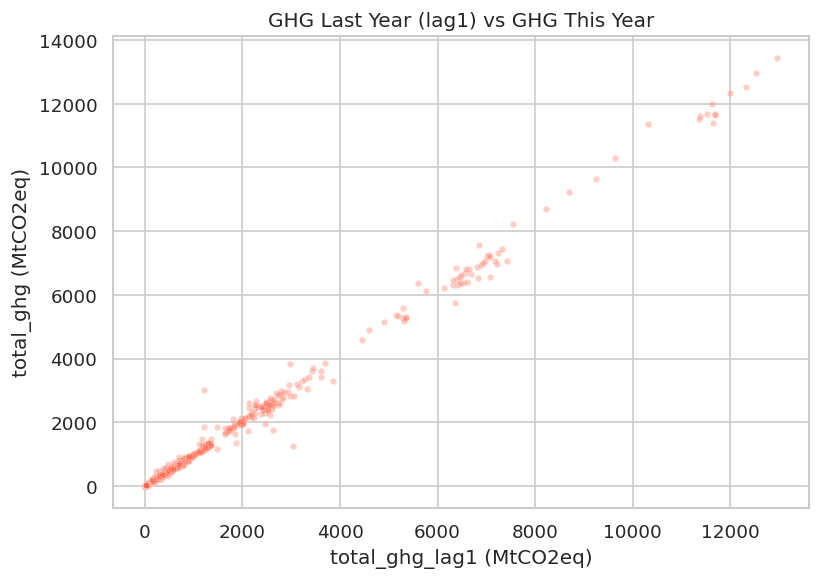

In [19]:
# Graph 5: Lag1 vs GHG
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df_model, x='total_ghg_lag1', y='total_ghg',
                alpha=0.3, s=15, color='tomato')
plt.title('GHG Last Year (lag1) vs GHG This Year')
plt.xlabel('total_ghg_lag1 (MtCO2eq)')
plt.ylabel('total_ghg (MtCO2eq)')
plt.tight_layout()
plt.savefig('eda_05_lag1_vs_ghg.png')
plt.show()

#### Graph 5: GHG Last Year (lag1) vs GHG This Year Scatter Plot
This scatter plot illustrates the strong relationship between the previous year's GHG emissions and the current year's emissions, highlighting the predictive power of lag features.

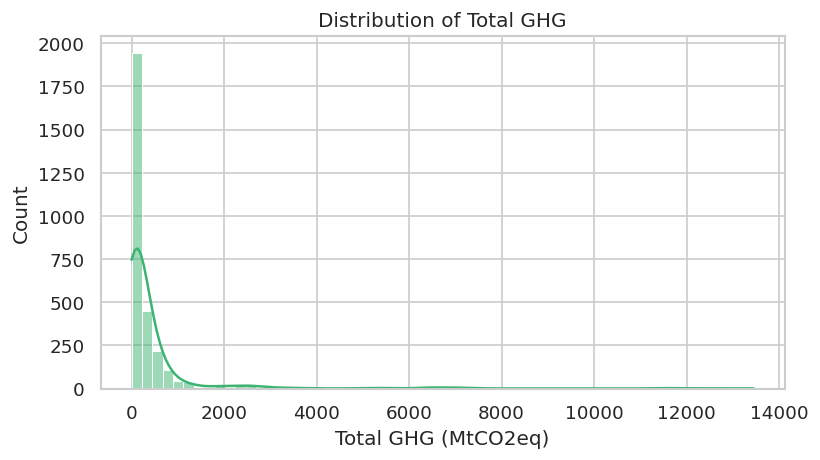

In [20]:
# Graph 6: Distribution of total_ghg
plt.figure(figsize=(7, 4))
sns.histplot(df_model['total_ghg'], bins=60, kde=True, color='mediumseagreen')
plt.title('Distribution of Total GHG')
plt.xlabel('Total GHG (MtCO2eq)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('eda_06_distribution.png')
plt.show()

#### Graph 6: Distribution of Total GHG Histogram
This histogram shows the distribution of the `total_ghg` variable. It helps assess the data's skewness and decide if transformations like logarithmic scaling are necessary for modeling.

## Step 4 — Train/Test Split

In [21]:
# Train/Test Split
train = df_model[df_model['year'] <= 2020].copy()
test  = df_model[df_model['year'] >= 2021].copy()

X_train, y_train = train[FEATURES], train[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

print(f'Train set: {X_train.shape[0]:,} rows  ({train["year"].min()}–{train["year"].max()})')
print(f'Test  set: {X_test.shape[0]:,} rows  ({test["year"].min()}–{test["year"].max()})')
print(f'Train countries: {train["country"].nunique()}')
print(f'Test  countries: {test["country"].nunique()}')

Train set: 2,758 rows  (1993–2020)
Test  set: 212 rows  (2021–2022)
Train countries: 108
Test  countries: 106


#### Time-Series Train/Test Split
This cell divides the prepared dataset (`df_model`) into training and testing sets based on the year. Data up to 2020 is used for training, and data from 2021 onwards is used for testing. This ensures that the model is evaluated on unseen future data.

## Step 5 — Model Comparison

We tested in 3 model:
- **Linear Regression** (baseline)
- **Random Forest** (ensemble tree)
- **Gradient Boosting** (boosted tree)

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

models = {
    'Linear Regression':  LinearRegression(),
    'Random Forest':      RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    'Gradient Boosting':  GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=42),
}

results = {}
preds   = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    results[name] = {'RMSE': round(rmse, 4), 'MAE': round(mae, 4), 'R²': round(r2, 4)}
    preds[name]   = y_pred
    print(f'{name:25s} | RMSE={rmse:.4f} | MAE={mae:.4f} | R²={r2:.4f}')

print('\n--- Summary Table ---')
print(pd.DataFrame(results).T.to_string())

Linear Regression         | RMSE=1.1564 | MAE=0.9313 | R²=0.4911
Random Forest             | RMSE=0.0864 | MAE=0.0595 | R²=0.9972
Gradient Boosting         | RMSE=0.0832 | MAE=0.0573 | R²=0.9974

--- Summary Table ---
                     RMSE     MAE      R²
Linear Regression  1.1564  0.9313  0.4911
Random Forest      0.0864  0.0595  0.9972
Gradient Boosting  0.0832  0.0573  0.9974


#### Model Training and Evaluation
This cell defines and initializes three different regression models: Linear Regression, Random Forest Regressor, and Gradient Boosting Regressor. It then trains each model on the `X_train` and `y_train` data, makes predictions on the `X_test` data, and calculates performance metrics (RMSE, MAE, R²) to compare their effectiveness.

## Step 6 — Visualize

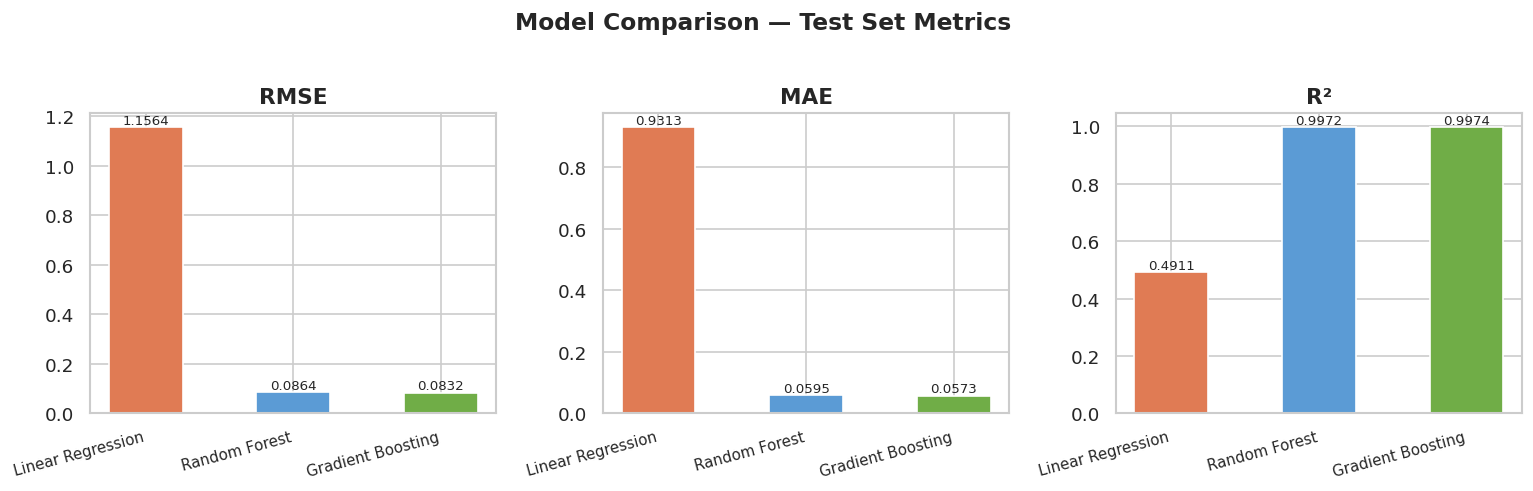

In [23]:
# Fig 1: Model Comparison Bar
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
metrics = ['RMSE', 'MAE', 'R²']
colors  = ['#e07b54', '#5b9bd5', '#70ad47']
for ax, metric in zip(axes, metrics):
    vals = [results[m][metric] for m in models]
    bars = ax.bar(list(models.keys()), vals, color=colors, width=0.5, edgecolor='white')
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(list(models.keys()), rotation=15, ha='right', fontsize=9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001, f'{v:.4f}',
                ha='center', va='bottom', fontsize=8)
fig.suptitle('Model Comparison — Test Set Metrics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('step6_01_model_comparison.png', bbox_inches='tight')
plt.show()

#### Figure 1: Model Comparison Bar Charts
This figure presents a series of bar charts comparing the performance of the three trained models across key metrics: Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and R-squared (R²). This visual comparison makes it easy to identify the best-performing model.

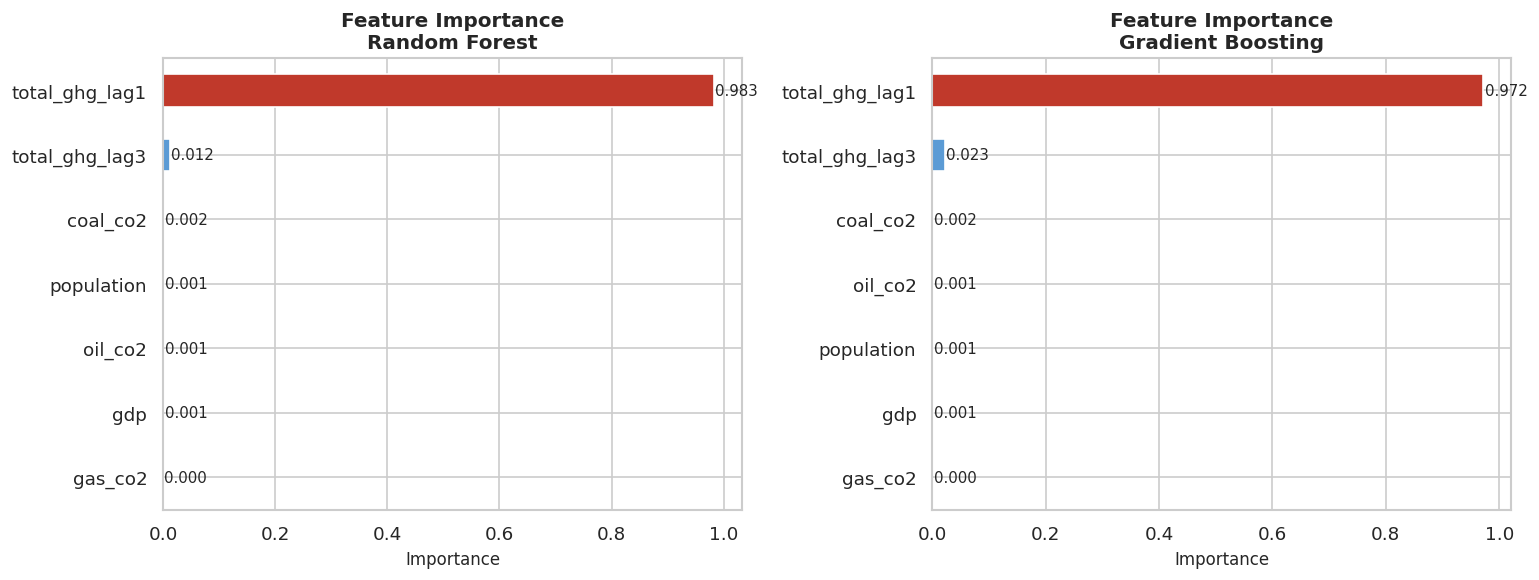

In [24]:
# Fig 2: Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, mname in zip(axes, ['Random Forest', 'Gradient Boosting']):
    model = models[mname]
    imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=True)
    colors_imp = ['#c0392b' if v == imp.max() else '#5b9bd5' for v in imp.values]
    imp.plot.barh(ax=ax, color=colors_imp, edgecolor='white')
    ax.set_title(f'Feature Importance\n{mname}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance', fontsize=10)
    for i, v in enumerate(imp.values):
        ax.text(v+0.002, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('step6_02_feature_importance.png', bbox_inches='tight')
plt.show()

#### Figure 2: Feature Importance for Ensemble Models
This figure displays bar charts showing the relative importance of each feature for the Random Forest and Gradient Boosting models. It helps understand which input variables contribute most significantly to the models' predictions.

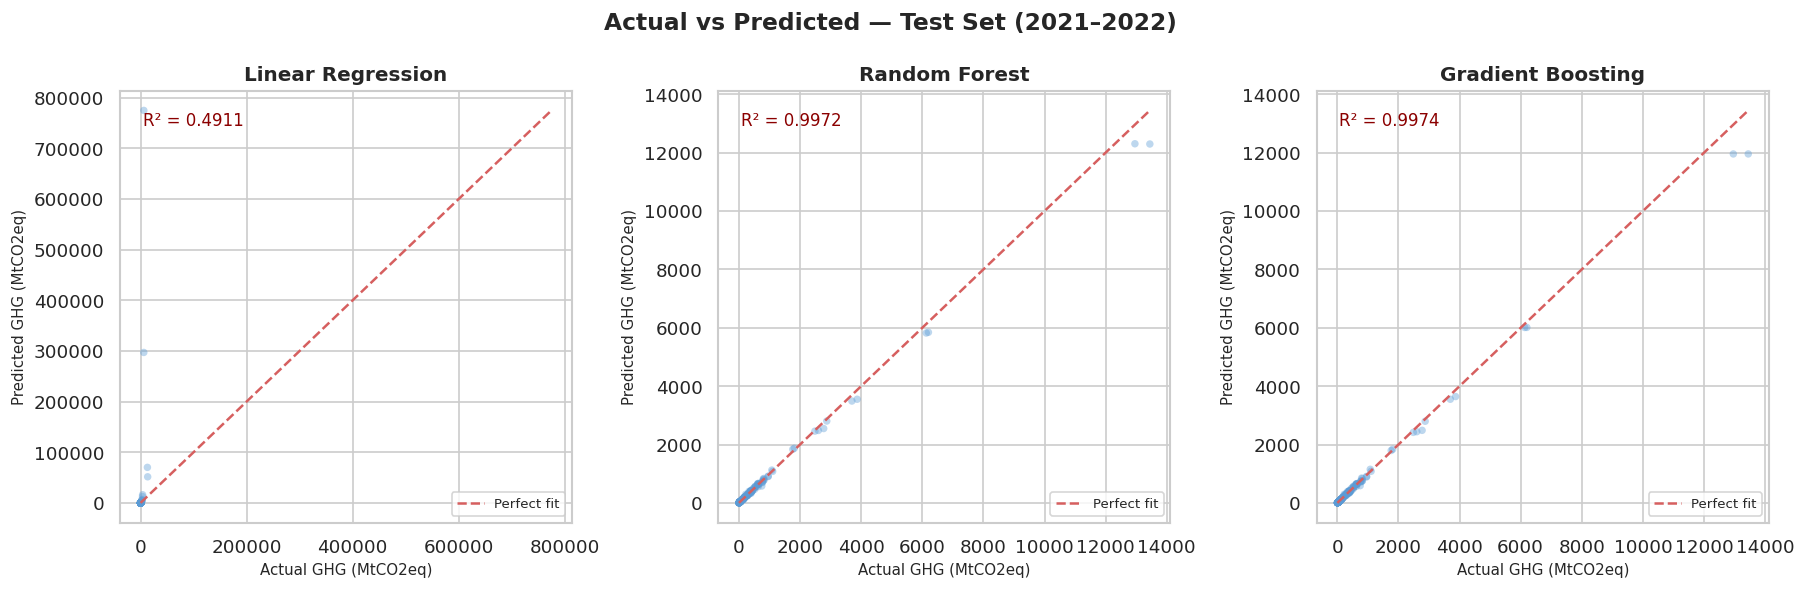

In [25]:
# Fig 3: Actual vs Predicted
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, y_pred) in zip(axes, preds.items()):
    y_actual   = np.expm1(y_test.values)
    y_pred_orig = np.expm1(y_pred)
    ax.scatter(y_actual, y_pred_orig, alpha=0.4, s=20, color='#5b9bd5', edgecolors='none')
    lims = [min(y_actual.min(), y_pred_orig.min()), max(y_actual.max(), y_pred_orig.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Actual GHG (MtCO2eq)', fontsize=9)
    ax.set_ylabel('Predicted GHG (MtCO2eq)', fontsize=9)
    ax.text(0.05, 0.92, f'R² = {results[name]["R²"]}', transform=ax.transAxes, fontsize=10, color='darkred')
    ax.legend(fontsize=8)
fig.suptitle('Actual vs Predicted — Test Set (2021–2022)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('step6_03_actual_vs_predicted.png', bbox_inches='tight')
plt.show()


#### Figure 3: Actual vs Predicted Values Scatter Plots
This figure contains scatter plots for each model, comparing the actual GHG emissions against the predicted emissions on the test set. A red dashed line represents a perfect fit (where actual equals predicted). These plots, along with the R² score, visually assess how well each model predicts the target variable.

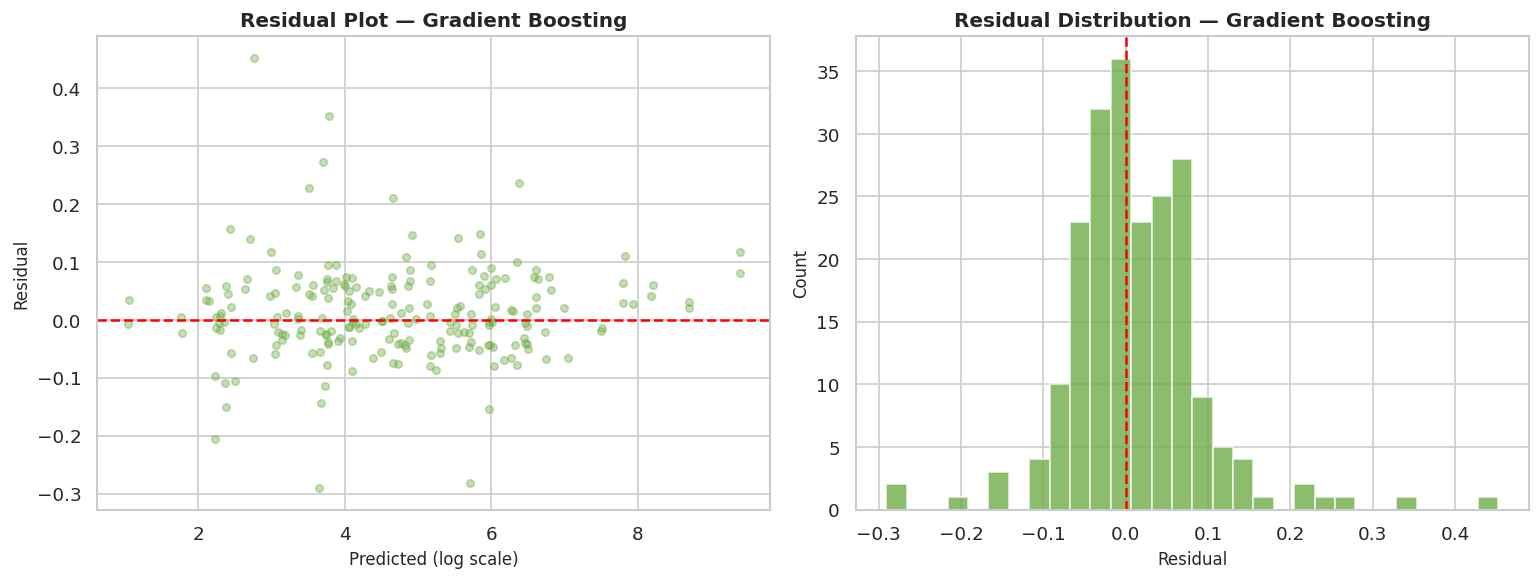

In [26]:
# Fig 4: Residual Analysis — Gradient Boosting (best model)
best_model = 'Gradient Boosting'
y_pred_best = preds[best_model]
residuals = y_test.values - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_pred_best, residuals, alpha=0.4, s=20, color='#70ad47')
axes[0].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[0].set_xlabel('Predicted (log scale)', fontsize=10)
axes[0].set_ylabel('Residual', fontsize=10)
axes[0].set_title(f'Residual Plot — {best_model}', fontsize=12, fontweight='bold')
axes[1].hist(residuals, bins=30, color='#70ad47', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Residual', fontsize=10)
axes[1].set_ylabel('Count', fontsize=10)
axes[1].set_title(f'Residual Distribution — {best_model}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('step6_04_residuals.png', bbox_inches='tight')
plt.show()


#### Figure 4: Residual Analysis for Gradient Boosting Model
This figure provides a residual analysis for the best-performing model, Gradient Boosting. It includes a scatter plot of residuals versus predicted values (to check for patterns) and a histogram of residuals (to assess their distribution). A good model typically shows randomly scattered residuals around zero and a normal-like distribution.